In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import warnings
from scipy.optimize import minimize
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

General GARCH Flow P -> Returns -> Variance -> z_t (Vol Units) -> Markov regime

sigma^2 = GARCH(1,1)

/var/folders/yk/03kntj1x0gxg37_rhl87gj800000gn/T/ipykernel_10369/1939483273.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('SPY', start='2018-01-01', end='2026-01-01')
[*********************100%***********************]  1 of 1 completed


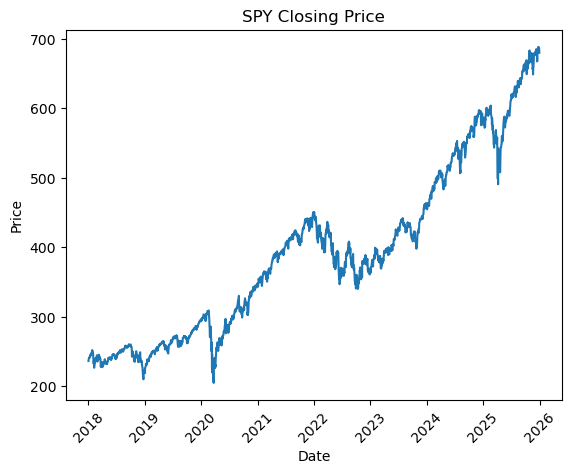

In [35]:
data = yf.download('SPY', start='2018-01-01', end='2026-01-01')
data.index = pd.to_datetime(data.index)
df = data['Close']
plt.plot(df)
plt.title('SPY Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()


/var/folders/yk/03kntj1x0gxg37_rhl87gj800000gn/T/ipykernel_10369/2053318599.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_returns'] = np.log(df).diff().dropna()
/var/folders/yk/03kntj1x0gxg37_rhl87gj800000gn/T/ipykernel_10369/2053318599.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


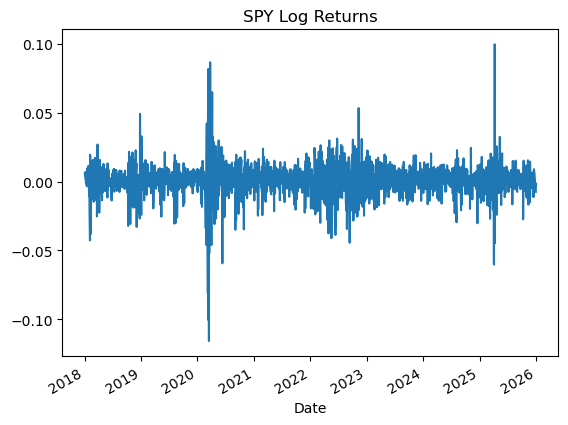

In [36]:
#Computing log returns
df['log_returns'] = np.log(df).diff().dropna()
df.dropna(inplace=True)
df['log_returns'].plot(title='SPY Log Returns')
plt.show()  
#Looking for where the returns cluster together can show periods of calm or periods of stress

Mean daily log return: 0.000525
Std daily log return:  0.012287
Skewness:              -0.5741
Excess kurtosis:       13.4986


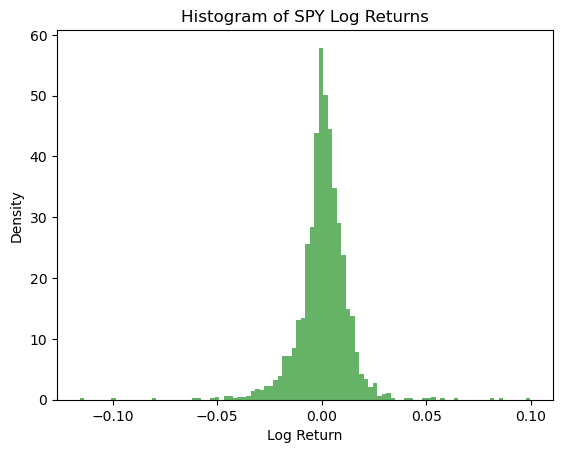

In [37]:
mean_ret = df["log_returns"].mean()
std_ret = df["log_returns"].std()
skew_ret = df["log_returns"].skew()
kurt_ret = df["log_returns"].kurtosis()

print(f"Mean daily log return: {mean_ret:.6f}")
print(f"Std daily log return:  {std_ret:.6f}")
print(f"Skewness:              {skew_ret:.4f}") #The tails of the data are skewing towrad the left
print(f"Excess kurtosis:       {kurt_ret:.4f}") #High excess kurtosis means we have fat tails, chances of extreme outliers
plt.hist(df['log_returns'], bins=100, density=True, alpha=0.6, color='g')
plt.title('Histogram of SPY Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Density')
plt.show()

In [38]:
#Markov Vol engine 
#Using the equation: sigma^2_t = omega + alpha * r^2_{t-1} + beta * sigma^2_{t-1}
def fit_garch11_variance(returns: pd.Series) -> pd.Series:
    values = returns.to_numpy(dtype=float)
    initial_variance = float(max(np.var(values), 1e-8))

    def unpack(theta: np.ndarray) -> tuple[float, float, float]:
        omega = float(np.exp(theta[0]))
        alpha_raw = float(np.exp(theta[1]))
        beta_raw = float(np.exp(theta[2]))

        # Force alpha + beta < 1 approximately
        scale = 1.0 + alpha_raw + beta_raw
        alpha = 0.995 * alpha_raw / scale
        beta = 0.995 * beta_raw / scale
        return omega, alpha, beta

    def neg_log_likelihood(theta: np.ndarray) -> float:
        omega, alpha, beta = unpack(theta)

        variance = np.empty_like(values)
        variance[0] = initial_variance

        for i in range(1, len(values)):
            variance[i] = omega + alpha * values[i - 1] ** 2 + beta * variance[i - 1]
            variance[i] = max(variance[i], 1e-10)

        # Gaussian quasi-log-likelihood up to constants
        nll = 0.5 * np.sum(np.log(variance) + (values ** 2) / variance)
        return float(nll)

    start = np.log(np.array([initial_variance * 0.05, 0.08, 0.90], dtype=float))
    opt = minimize(neg_log_likelihood, start, method="L-BFGS-B")

    omega, alpha, beta = unpack(opt.x if opt.success else start)

    variance = np.empty_like(values)
    variance[0] = initial_variance
    for i in range(1, len(values)):
        variance[i] = omega + alpha * values[i - 1] ** 2 + beta * variance[i - 1]
        variance[i] = max(variance[i], 1e-10)

    print("Optimization success:", opt.success)
    print(f"omega = {omega:.8f}")
    print(f"alpha = {alpha:.6f}")
    print(f"beta  = {beta:.6f}")
    print(f"alpha + beta = {alpha + beta:.6f}")

    return pd.Series(variance, index=returns.index, name="garch_variance")

Optimization success: True
omega = 0.00000494
alpha = 0.164016
beta  = 0.800088
alpha + beta = 0.964104


/var/folders/yk/03kntj1x0gxg37_rhl87gj800000gn/T/ipykernel_10369/240823721.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['garch_variance'] = fit_garch11_variance(df['log_returns'])
/var/folders/yk/03kntj1x0gxg37_rhl87gj800000gn/T/ipykernel_10369/240823721.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['garch_volatility'] = np.sqrt(df['garch_variance'])


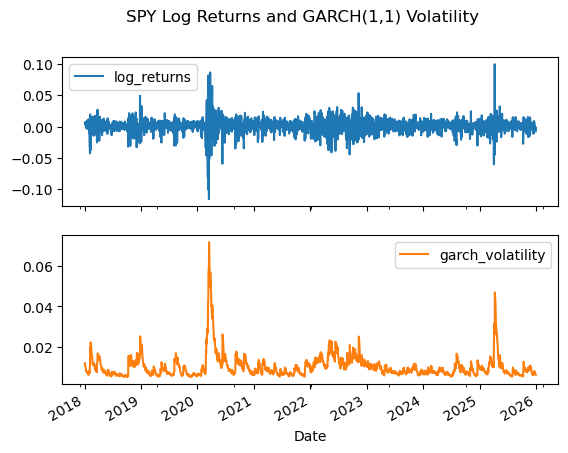

In [39]:
df['garch_variance'] = fit_garch11_variance(df['log_returns'])
df['garch_volatility'] = np.sqrt(df['garch_variance'])
df[['log_returns', 'garch_volatility']].plot(subplots=True, title='SPY Log Returns and GARCH(1,1) Volatility')
plt.show()  

/var/folders/yk/03kntj1x0gxg37_rhl87gj800000gn/T/ipykernel_10369/906239772.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['standardized_returns'] = df['log_returns'] / df['garch_volatility']


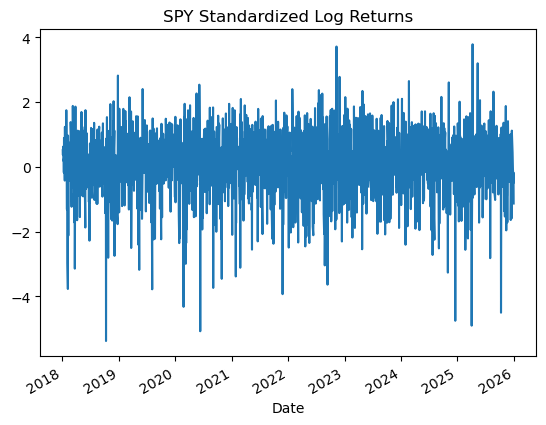

<Axes: >

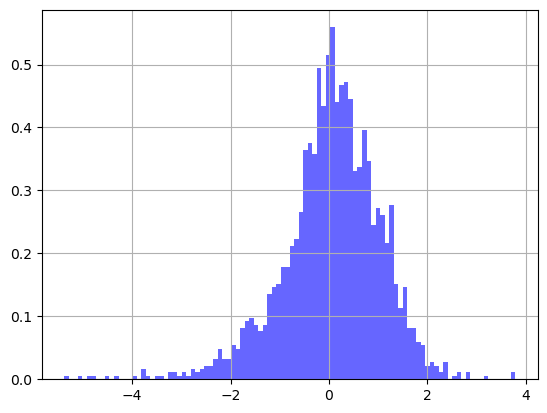

In [40]:
#Standardized GARCH returns
#This puts the returns in terms of Vol or vol-adjusted units
df['standardized_returns'] = df['log_returns'] / df['garch_volatility']
df['standardized_returns'].plot(title='SPY Standardized Log Returns')
plt.show()
df['standardized_returns'].hist(bins=100, density=True, alpha=0.6, color='b')

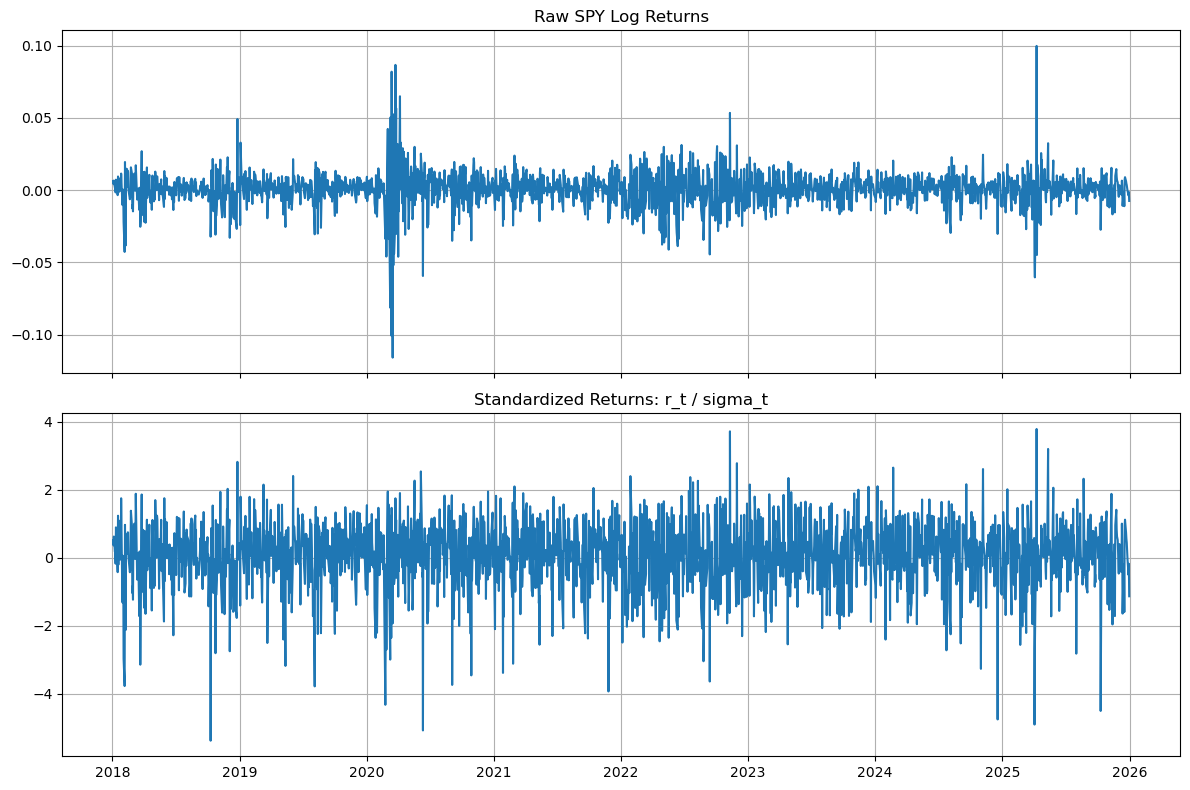

In [41]:
#Comparing the raw and standarized returns
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df.index, df["log_returns"])
axes[0].set_title("Raw SPY Log Returns")
axes[0].grid(True)

axes[1].plot(df.index, df["standardized_returns"])
axes[1].set_title("Standardized Returns: r_t / sigma_t")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
#Fitting a two regime Markov Switching GARCH model
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)

    model = MarkovRegression(
        df["standardized_returns"],
        k_regimes=2,
        trend="c",
        switching_variance=True,
    )

    result = model.fit(disp=False, maxiter=200, em_iter=10)

print(result.summary())


#Extracting the smoothed probabilities of being in each regime
#Based on the equation P(S_t = j | F_t) filteration is based on the information given at time t
probs = result.filtered_marginal_probabilities

if not isinstance(probs, pd.DataFrame):
    probs = pd.DataFrame(probs, index=df.index, columns=[0, 1])

probs.columns = ["state_0_prob", "state_1_prob"]
probs.tail()

                         Markov Switching Model Results                         
Dep. Variable:     standardized_returns   No. Observations:                 2010
Model:                 MarkovRegression   Log Likelihood               -2762.531
Date:                  Sat, 28 Mar 2026   AIC                           5537.062
Time:                          12:15:37   BIC                           5570.697
Sample:                               0   HQIC                          5549.409
                                 - 2010                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2224      0.032      6.951      0.000       0.160       0.285
sigma2         0.5848      0.047    

/opt/anaconda3/envs/ram/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,state_0_prob,state_1_prob
Date,,
2025-12-24,0.921381,0.078619
2025-12-26,0.906286,0.093714
2025-12-29,0.852045,0.147955
2025-12-30,0.881339,0.118661
2025-12-31,0.655413,0.344587


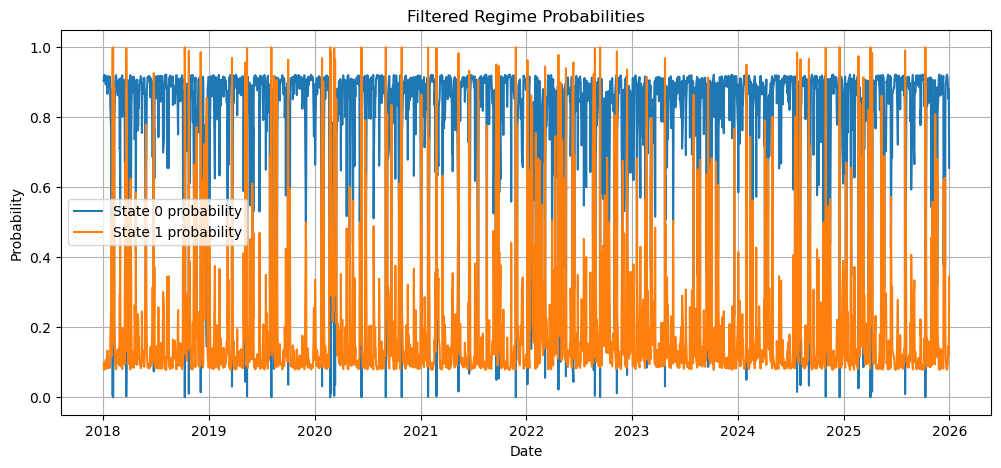

In [45]:
plt.figure(figsize=(12, 5))
plt.plot(probs.index, probs["state_0_prob"], label="State 0 probability")
plt.plot(probs.index, probs["state_1_prob"], label="State 1 probability")
plt.title("Filtered Regime Probabilities")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.show()

In [46]:
def weighted_state_stats(returns: pd.Series, variance: pd.Series, weights: pd.Series) -> tuple[float, float]:
    aligned_returns = returns.loc[weights.index].to_numpy(dtype=float)
    aligned_variance = variance.loc[weights.index].to_numpy(dtype=float)
    aligned_weights = weights.to_numpy(dtype=float)

    total_weight = float(aligned_weights.sum())
    if total_weight <= 1e-12:
        return 0.0, float(np.sqrt(np.nanmean(aligned_variance)))

    mean_return = float(np.dot(aligned_returns, aligned_weights) / total_weight)
    avg_vol = float(np.dot(np.sqrt(aligned_variance), aligned_weights) / total_weight)
    return mean_return, avg_vol

In [47]:
#Estimating state mean and volatility
# mu_hat = sum(w_i * r_i) / sum(w_i)
#sigma_hat = sum(w_i * sigma_i) / sum(w_i)

state_summary = []

for state_col in probs.columns:
    mean_ret, avg_vol = weighted_state_stats(
        df["log_returns"],
        df["garch_variance"],
        probs[state_col]
    )
    state_summary.append((state_col, mean_ret, avg_vol))

state_summary_df = pd.DataFrame(
    state_summary,
    columns=["state", "weighted_mean_return", "weighted_avg_volatility"]
)

state_summary_df

,state,weighted_mean_return,weighted_avg_volatility
0,state_0_prob,0.002259,0.01053
1,state_1_prob,-0.006345,0.01109


In [48]:
#Labeling, designed by chatgpt
state_summary_df = state_summary_df.sort_values("weighted_mean_return").reset_index(drop=True)

state_label_map = {
    state_summary_df.loc[0, "state"]: "bearish_or_weak",
    state_summary_df.loc[1, "state"]: "bullish_or_strong",
}

state_label_map

{'state_1_prob': 'bearish_or_weak', 'state_0_prob': 'bullish_or_strong'}

In [ ]:
#Regime label, desing by chatgpt and me
regime_frame = df.copy()
regime_frame["state_0_prob"] = probs["state_0_prob"]
regime_frame["state_1_prob"] = probs["state_1_prob"]

for raw_state, label in state_label_map.items():
    regime_frame[f"{label}_prob"] = regime_frame[raw_state]

regime_frame["regime"] = np.where(
    regime_frame["bullish_or_strong_prob"] >= regime_frame["bearish_or_weak_prob"],
    "bullish_or_strong",
    "bearish_or_weak"
)

regime_frame["confidence"] = regime_frame[["bullish_or_strong_prob", "bearish_or_weak_prob"]].max(axis=1) #Extracting the regime prob

regime_frame[[
    "log_returns",
    "garch_variance",
    "bullish_or_strong_prob",
    "bearish_or_weak_prob",
    "regime",
    "confidence"
]].tail()

Ticker,log_returns,garch_variance,bullish_or_strong_prob,bearish_or_weak_prob,regime,confidence
Date,,,,,,
2025-12-24,0.003511,0.000062,0.921381,0.078619,bullish_or_strong,0.921381
2025-12-26,-0.000101,0.000057,0.906286,0.093714,bullish_or_strong,0.906286
2025-12-29,-0.003570,0.000050,0.852045,0.147955,bullish_or_strong,0.852045
2025-12-30,-0.001222,0.000047,0.881339,0.118661,bullish_or_strong,0.881339
2025-12-31,-0.007437,0.000043,0.655413,0.344587,bullish_or_strong,0.655413


In [52]:
regime_frame

Ticker,SPY,log_returns,garch_variance,garch_volatility,standardized_returns,state_0_prob,state_1_prob,bearish_or_weak_prob,bullish_or_strong_prob,regime,confidence
Date,,,,,,,,,,,
2018-01-03,238.058350,0.006305,0.000151,0.012284,0.513258,0.903667,0.096333,0.096333,0.903667,bullish_or_strong,0.903667
2018-01-04,239.061798,0.004206,0.000132,0.011497,0.365855,0.917719,0.082281,0.082281,0.917719,bullish_or_strong,0.917719
2018-01-05,240.654938,0.006642,0.000114,0.010658,0.623171,0.921286,0.078714,0.078714,0.921286,bullish_or_strong,0.921286
2018-01-08,241.095032,0.001827,0.000103,0.010152,0.179966,0.915402,0.084598,0.084598,0.915402,bullish_or_strong,0.915402
2018-01-09,241.640701,0.002261,0.000088,0.009378,0.241060,0.916506,0.083494,0.083494,0.916506,bullish_or_strong,0.916506
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,688.499695,0.003511,0.000062,0.007897,0.444628,0.921381,0.078619,0.078619,0.921381,bullish_or_strong,0.921381
2025-12-26,688.429871,-0.000101,0.000057,0.007541,-0.013449,0.906286,0.093714,0.093714,0.906286,bullish_or_strong,0.906286
2025-12-29,685.976562,-0.003570,0.000050,0.007102,-0.502663,0.852045,0.147955,0.147955,0.852045,bullish_or_strong,0.852045


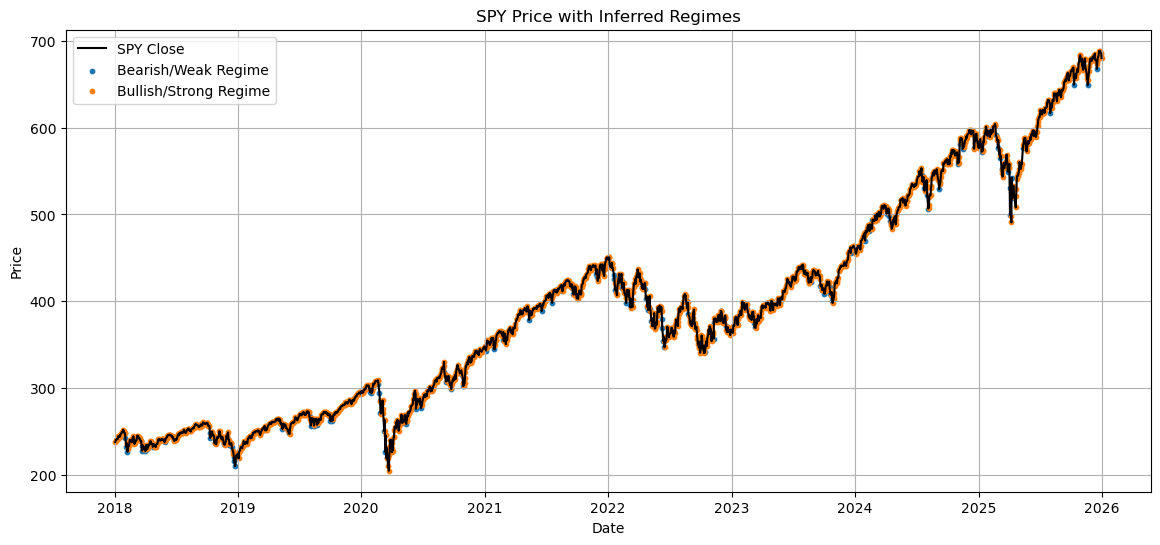

In [55]:
plt.figure(figsize=(14, 6))
plt.plot(regime_frame.index, regime_frame["SPY"], label="SPY Close", color="black")

bear_mask = regime_frame["regime"] == "bearish_or_weak"
bull_mask = regime_frame["regime"] == "bullish_or_strong"

plt.scatter(
    regime_frame.index[bear_mask],
    regime_frame["SPY"][bear_mask],
    s=10,
    label="Bearish/Weak Regime"
)

plt.scatter(
    regime_frame.index[bull_mask],
    regime_frame["SPY"][bull_mask],
    s=10,
    label="Bullish/Strong Regime"
)

plt.title("SPY Price with Inferred Regimes")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
regime_frame["guarded_regime"] = np.where( #Determines the regime based on the confidence. This is a two regime model so neutral regime could fall into the middle
    regime_frame["confidence"] < 0.55,
    "uncertain",
    regime_frame["regime"]
)

regime_frame["guarded_regime"].value_counts() #Guarded regimes help us in biasing my decision making so I am not trading during no classified regime states

guarded_regime
bullish_or_strong    1814
bearish_or_weak       155
uncertain              41
Name: count, dtype: int64

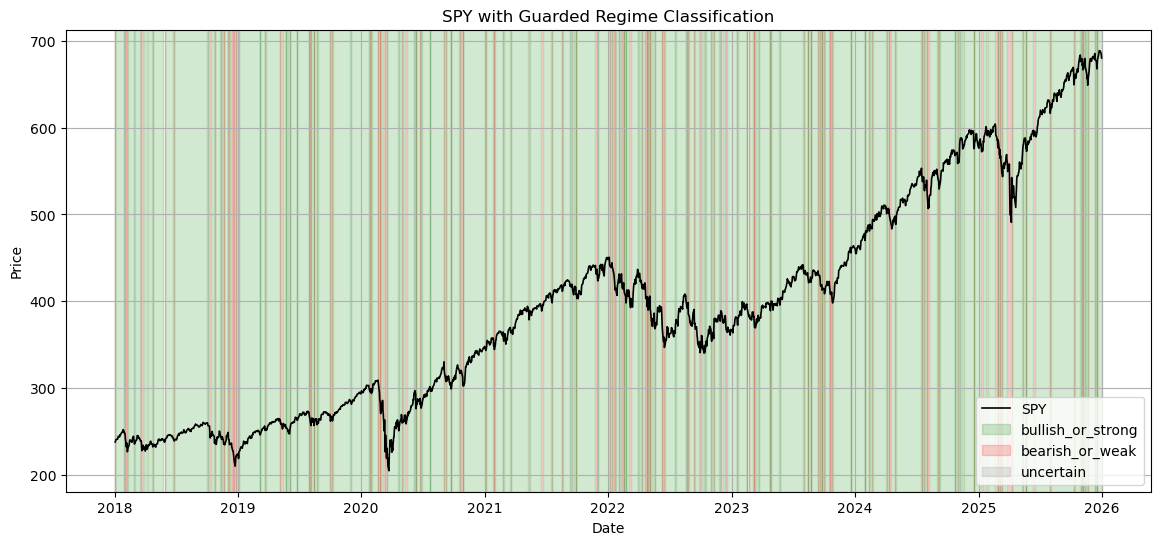

In [59]:
import matplotlib.pyplot as plt

colors = {
    "bullish_or_strong": "green",
    "bearish_or_weak": "red",
    "uncertain": "gray"
}

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(regime_frame.index, regime_frame["SPY"], color="black", linewidth=1.2, label="SPY")

# Find contiguous blocks where the regime stays the same
regime_changes = (regime_frame["guarded_regime"] != regime_frame["guarded_regime"].shift()).cumsum()

for _, block in regime_frame.groupby(regime_changes):
    regime = block["guarded_regime"].iloc[0]
    start = block.index[0]
    end = block.index[-1]
    
    ax.axvspan(start, end, color=colors.get(regime, "gray"), alpha=0.18)

# Create a clean legend for the shaded regimes
for regime_name, color in colors.items():
    ax.axvspan(
        regime_frame.index[0],
        regime_frame.index[0],
        color=color,
        alpha=0.18,
        label=regime_name
    )

ax.set_title("SPY with Guarded Regime Classification")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
ax.grid(True)
plt.show()